## Project Goal
The goal of this project is to build a computer vision pipeline to classify skin lesions into two categories:
1. **Melanocytic Nevus** (Benign)
2. **Melanoma** (Malignant)

I will implement a pipeline consisting of:
1. **Segmentation:** Isolating the lesion from the skin using K-Means clustering.
2. **Pre-processing:** Improving image quality with Color Constancy and CLAHE.
3. **Feature Extraction:** Extracting **ABCD** clinical features (Asymmetry, Border, Color, Diameter) and texture (GLCM + LBP).
4. **Classification:** Training a **Random Forest** classifier to predict the class.

## Step 1: Data Acquisition & Setup
In this step, I load the dataset.
Since the dataset contains 9 categories, I filter it to keep only the two required classes: **Melanoma** and **Nevus**.
I also split the data into a Training set (80%) and a Test set (20%) to evaluate performance later.

In [1]:
# Imports
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Data paths. I put image files in ../data/raw and the CSV in ../data
DATA_DIR = "../data/raw" 
CSV_PATH = "../data/ISIC_2019_Training_GroundTruth.csv"

# 1. Load the CSV
df = pd.read_csv(CSV_PATH)

# 2. Filter for only Melanoma (MEL) and Nevus (NV)
df_filtered = df[(df['MEL'] == 1) | (df['NV'] == 1)].copy()

# 3. Create a single 'label' column for binary classification
# Let's map: Nevus (NV) -> 0 (Benign), Melanoma (MEL) -> 1 (Malignant)
df_filtered['label'] = df_filtered['MEL'].apply(lambda x: 1 if x == 1 else 0)
df_filtered['class_name'] = df_filtered['label'].apply(lambda x: 'Melanoma' if x == 1 else 'Nevus')

print(f"Filtered dataset size: {len(df_filtered)}")
print(df_filtered['class_name'].value_counts())

# 4. Split into Train/Test
train_df, test_df = train_test_split(
    df_filtered, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_filtered['label']
)

# Add full file paths
train_df['path'] = train_df['image'].apply(lambda x: os.path.join(DATA_DIR, x + '.jpg'))
test_df['path'] = test_df['image'].apply(lambda x: os.path.join(DATA_DIR, x + '.jpg'))

print(f"\nTraining samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Filtered dataset size: 17397
class_name
Nevus       12875
Melanoma     4522
Name: count, dtype: int64

Training samples: 13917
Testing samples: 3480


## Step 2 & 3: Segmentation and Pre-processing Helpers
To extract features accurately, I need to isolate the lesion from the healthy skin.

**Techniques used:**
1. **Color Constancy (Gray World Algorithm):** This removes color casts caused by different lighting conditions (e.g., yellow indoor light vs. white flash).
2. **K-Means Clustering:** To separate the image into "Skin" and "Lesion" based on color.
3. **CLAHE:** To enhance local contrast and make the texture of the lesion more visible.

In [3]:
def color_constancy(image, power=6):
    """
    Applies Gray World assumption to normalize image illumination.
    """
    image_float = image.astype(np.float32)
    
    # Calculate Minkowski norm
    r_mean = np.power(np.mean(np.power(image_float[:,:,0], power)), 1/power)
    g_mean = np.power(np.mean(np.power(image_float[:,:,1], power)), 1/power)
    b_mean = np.power(np.mean(np.power(image_float[:,:,2], power)), 1/power)
    
    gray_mean = (r_mean + g_mean + b_mean) / 3
    
    # Normalize
    image_normalized = image_float.copy()
    image_normalized[:,:,0] = image_normalized[:,:,0] * (gray_mean / r_mean)
    image_normalized[:,:,1] = image_normalized[:,:,1] * (gray_mean / g_mean)
    image_normalized[:,:,2] = image_normalized[:,:,2] * (gray_mean / b_mean)
    
    return np.clip(image_normalized, 0, 255).astype(np.uint8)

def segment_lesion_from_image(image_rgb):
    """
    Segments the skin lesion using K-Means clustering on the image array.
    """
    # Reshape for K-means
    pixel_values = image_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # K-Means (k=2: Skin vs Lesion)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 2
    _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    centers = np.uint8(centers)
    
    # Determine which cluster is the lesion (usually darker)
    if np.sum(centers[0]) < np.sum(centers[1]):
        lesion_cluster = 0
    else:
        lesion_cluster = 1
        
    mask = (labels.flatten() == lesion_cluster).reshape(image_rgb.shape[:2])
    mask = mask.astype(np.uint8) * 255 

    # Morphological Cleanup (Remove hair/noise)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    result = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    return image_rgb, mask, result

def preprocess_image(image_rgb, mask):
    """
    Applies Median Blur (denoising) and CLAHE (contrast enhancement).
    """
    # 1. Denoise
    denoised = cv2.medianBlur(image_rgb, 5)
    
    # 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    lab_enhanced = cv2.merge((l_enhanced, a, b))
    enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)
    
    # 3. Mask again
    final_result = cv2.bitwise_and(enhanced, enhanced, mask=mask)
    return final_result

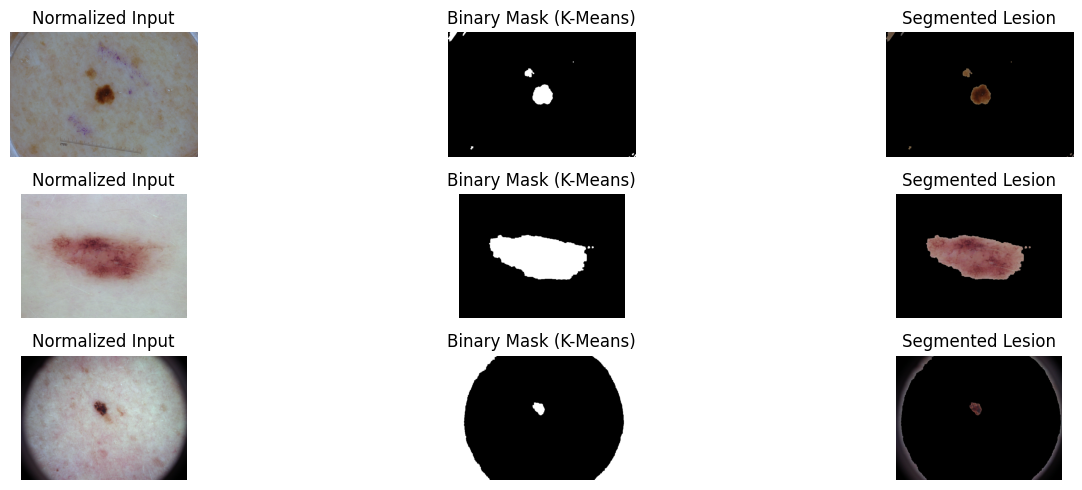

In [ ]:
# --- VISUALIZATION 1: SEGMENTATION STEPS ---
# Select 3 random samples to inspect
sample_paths = train_df['path'].sample(3).values

plt.figure(figsize=(15, 5))

for i, path in enumerate(sample_paths):
    # 1. Load & Normalize
    image_bgr = cv2.imread(path)
    if image_bgr is None: continue
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    # We use the normalized image because that's what the algorithm sees
    image_norm = color_constancy(image_rgb)
    
    # 2. Segment
    _, mask, segmented = segment_lesion_from_image(image_norm)
    
    # 3. Plotting
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(image_norm)
    plt.title("Normalized Input")
    plt.axis('off')
    
    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Binary Mask (K-Means)")
    plt.axis('off')
    
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(segmented)
    plt.title("Segmented Lesion")
    plt.axis('off')

plt.tight_layout()
plt.show()

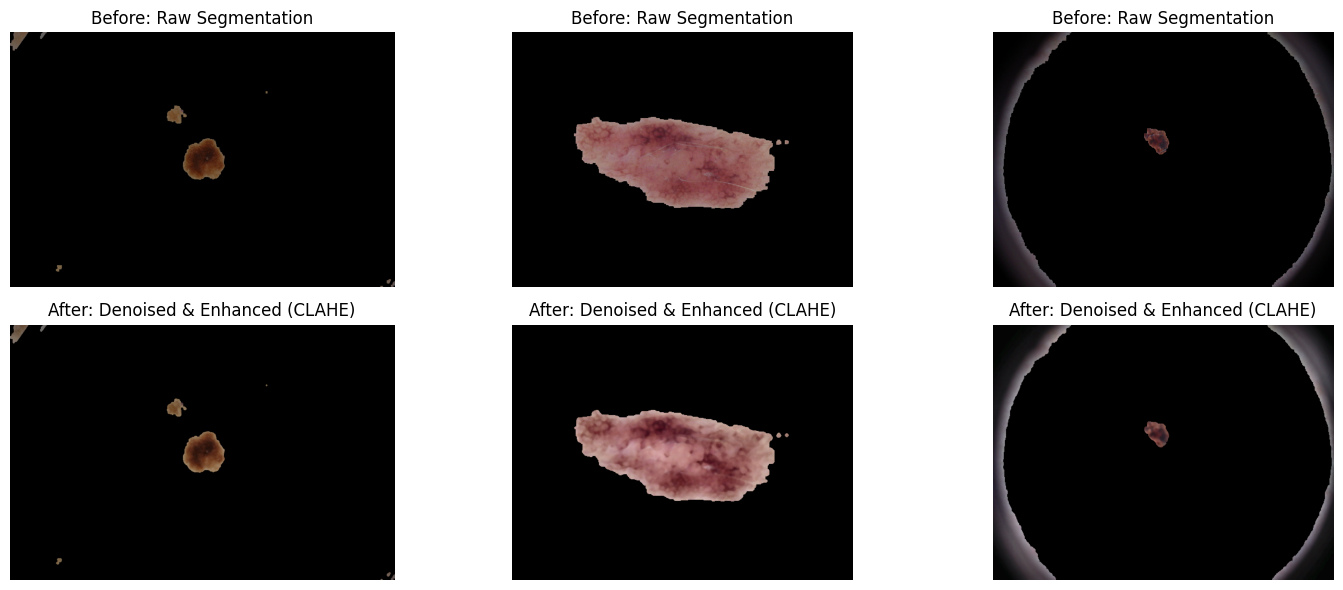

In [5]:
# --- VISUALIZATION 2: PRE-PROCESSING QUALITY ---
# "Raw Segmented" vs "Denoised + Enhanced"

plt.figure(figsize=(15, 6))

for i, path in enumerate(sample_paths):
    # 1. Load & Normalize
    image_bgr = cv2.imread(path)
    if image_bgr is None: continue
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_norm = color_constancy(image_rgb)
    
    # 2. Segment (Step 2)
    _, mask, segmented_raw = segment_lesion_from_image(image_norm)
    
    # 3. Pre-process (Step 3: Denoise + CLAHE)
    processed_lesion = preprocess_image(segmented_raw, mask)
    
    # 4. Plot Comparison
    plt.subplot(2, 3, i + 1)
    plt.imshow(segmented_raw)
    plt.title("Before: Raw Segmentation")
    plt.axis('off')
    
    plt.subplot(2, 3, i + 4)
    plt.imshow(processed_lesion)
    plt.title("After: Denoised & Enhanced (CLAHE)")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 4: Feature Extraction (ABCD Rule & LBP)
I convert the visual information into numerical vectors using the **ABCD Rule**:

* **Shape:** Area, Perimeter, Compactness (Border Irregularity).
* **Color:** Mean and Standard Deviation of RGB channels (Color Variegation).
* **Texture:**
    * **GLCM:** Contrast, Homogeneity.
    * **LBP (Local Binary Patterns):** Captures micro-texture patterns to distinguish complex melanoma surfaces.

In [6]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

def extract_features(image, mask):
    features = {}
    
    # --- 1. SHAPE & BORDER ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0: return None
    
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    
    if area > 0: compactness = (perimeter ** 2) / (4 * np.pi * area)
    else: compactness = 0
        
    features['area'] = area
    features['perimeter'] = perimeter
    features['compactness'] = compactness
    
    # --- 2. COLOR ---
    mean_color, std_color = cv2.meanStdDev(image, mask=mask)
    features['mean_r'] = mean_color[0][0]; features['mean_g'] = mean_color[1][0]; features['mean_b'] = mean_color[2][0]
    features['std_r'] = std_color[0][0]; features['std_g'] = std_color[1][0]; features['std_b'] = std_color[2][0]

    # --- 3. TEXTURE (GLCM + LBP) ---
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    x, y, w, h = cv2.boundingRect(cnt)
    roi_gray = gray[y:y+h, x:x+w]
    
    # A. GLCM
    glcm = graycomatrix(roi_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features['contrast'] = graycoprops(glcm, 'contrast')[0, 0]
    features['homogeneity'] = graycoprops(glcm, 'homogeneity')[0, 0]
    features['energy'] = graycoprops(glcm, 'energy')[0, 0]
    features['correlation'] = graycoprops(glcm, 'correlation')[0, 0]

    # B. Local Binary Patterns (LBP)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(roi_gray, n_points, radius, method="uniform")
    
    (lbp_hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= (lbp_hist.sum() + 1e-7)

    features['lbp_1'] = lbp_hist[0]
    features['lbp_2'] = lbp_hist[1]
    features['lbp_energy'] = np.sum(lbp_hist ** 2) 
    features['lbp_entropy'] = -np.sum(lbp_hist * np.log2(lbp_hist + 1e-7))

    return features

In [7]:
# --- PROCESS TRAINING SET ---
X_data = []
y_labels = []

print("Extracting features from Training Set...")

for index, row in train_df.iterrows():
    # 1. Load
    image_bgr = cv2.imread(row['path'])
    if image_bgr is None: continue
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    # 2. Normalize (Color Constancy)
    image_norm = color_constancy(image_rgb)
    
    # 3. Segment
    original, mask, _ = segment_lesion_from_image(image_norm)
    
    # 4. Pre-process
    processed = preprocess_image(original, mask)
    
    # 5. Extract
    feats = extract_features(processed, mask)
    
    if feats is not None:
        X_data.append(list(feats.values()))
        y_labels.append(row['label'])
        
    if index % 200 == 0:
        print(f"Processed {index} images")

X = np.array(X_data)
y = np.array(y_labels)
feature_names = list(feats.keys())
print(f"Done. Training Matrix: {X.shape}")

Extracting features from Training Set...
Processed 6200 images
Processed 10200 images
Processed 13000 images
Processed 400 images
Processed 14200 images
Processed 19800 images
Processed 10000 images
Processed 21800 images
Processed 15600 images
Processed 3200 images
Processed 3400 images
Processed 22400 images
Processed 17600 images
Processed 7200 images
Processed 12400 images
Processed 21600 images
Processed 10600 images
Processed 18400 images
Processed 22200 images
Processed 11400 images
Processed 2000 images
Processed 5200 images
Processed 2600 images
Processed 9800 images
Processed 800 images
Processed 7800 images
Processed 6600 images
Processed 11200 images
Processed 22600 images
Processed 13400 images
Processed 8400 images
Processed 25000 images
Processed 15800 images
Processed 12200 images
Processed 15200 images
Processed 9200 images
Processed 12000 images
Processed 16800 images
Processed 13200 images
Processed 3800 images
Processed 10400 images
Processed 12800 images
Processed 

In [8]:
# --- PROCESS TEST SET ---
X_test_data = []
y_test_labels = []

print("Extracting features from Test Set...")

for index, row in test_df.iterrows():
    image_bgr = cv2.imread(row['path'])
    if image_bgr is None: continue
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    image_norm = color_constancy(image_rgb)
    original, mask, _ = segment_lesion_from_image(image_norm)
    processed = preprocess_image(original, mask)
    feats = extract_features(processed, mask)
    
    if feats is not None:
        X_test_data.append(list(feats.values()))
        y_test_labels.append(row['label'])

X_test = np.array(X_test_data)
y_test = np.array(y_test_labels)
print(f"Done. Test Matrix: {X_test.shape}")

Extracting features from Test Set...
Done. Test Matrix: (3480, 17)


## Step 5: Classification & Evaluation
I use a **Random Forest Classifier** to train the model.
* I chose Random Forest because it handles the combination of different feature types (shape, color, texture) well and is robust to noise.
* I use `class_weight='balanced'` to handle the dataset imbalance.

**Evaluation:**
I check the **Recall** score. High recall for Melanoma is crucial because missing a malignant case is dangerous.

Training Random Forest...

=== Classification Metrics ===


,precision,recall,f1-score,support
Nevus,0.87,0.82,0.84,2575.00
Melanoma,0.56,0.64,0.60,905.00
accuracy,0.77,0.77,0.77,0.77
macro avg,0.71,0.73,0.72,3480.00
weighted avg,0.79,0.77,0.78,3480.00


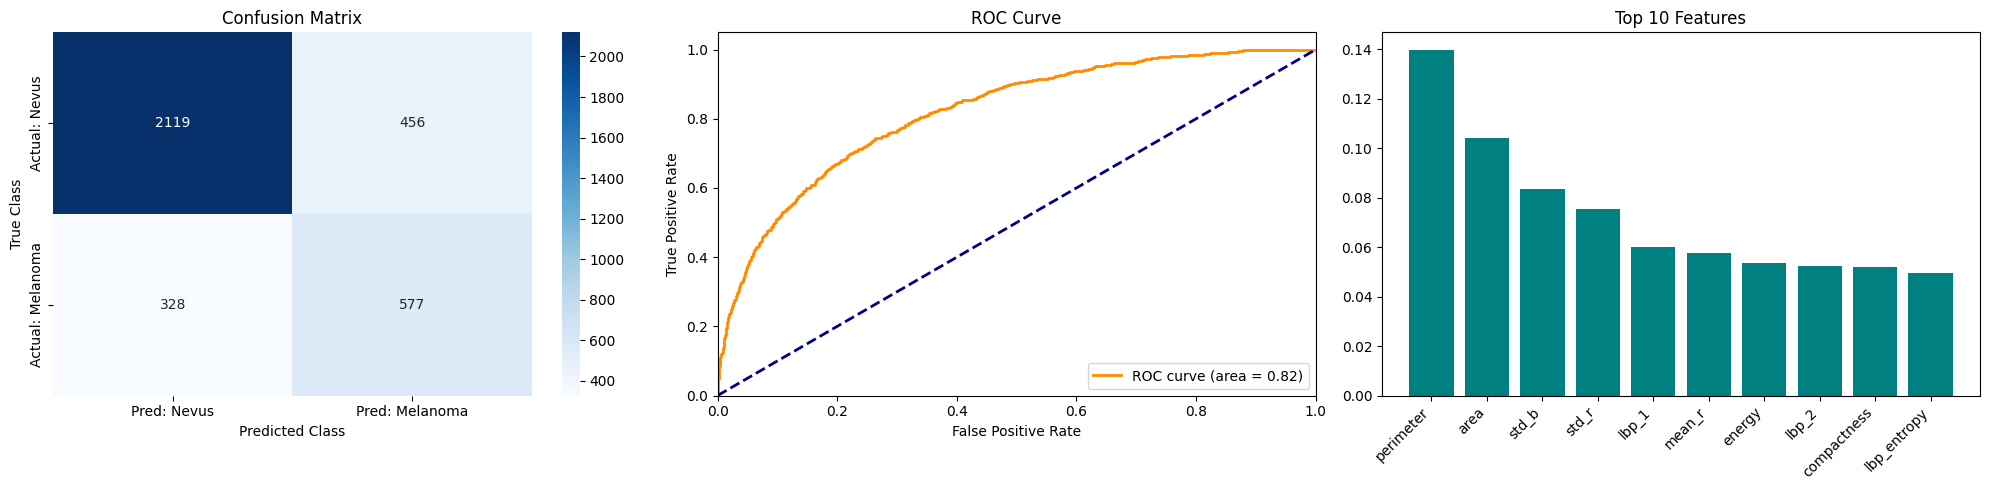

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# 2. Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, 
                                  random_state=42, 
                                  class_weight='balanced',
                                  max_depth=10) 
rf_model.fit(X_train_scaled, y)

# 3. Get Predictions
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1] # Probability of Melanoma

# --- OUTPUTS FOR REPORT ---

# A. Metrics Table
report_dict = classification_report(y_test, y_pred, target_names=['Nevus', 'Melanoma'], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("\n=== Classification Metrics ===")
display(report_df.round(2))

# B. Create Dashboard of Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Nevus', 'Pred: Melanoma'],
            yticklabels=['Actual: Nevus', 'Actual: Melanoma'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Class')
axes[0].set_xlabel('Predicted Class')

# Plot 2: ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# Plot 3: Top Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
axes[2].bar(range(top_n), importances[indices[:top_n]], align="center", color='teal')
axes[2].set_xticks(range(top_n))
axes[2].set_xticklabels([feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
axes[2].set_title('Top 10 Features')

plt.tight_layout()
plt.show()